In [12]:
#Load datasets

import pandas as pd

# Paired dataset of "Example in genz slang" - "Example equivalent normal"
pairs = pd.read_csv("hf://datasets/Programmer-RD-AI/genz-slang-pairs-1k/genz_dataset.csv")

# Big slang dictionary with: SLANG, DESCRIPTION, EXAMPLE, CONTEXT
slang_dict_hf = pd.read_csv("hf://datasets/MLBtrio/genz-slang-dataset/all_slangs.csv")

# SLANG, DESCRIPTION, EXAMPLE, POPULARITY
slang_dict_kaggle = pd.read_csv("/Users/pablobondiaportoles/Desktop/Project_NLP/Data/genz_slang_with_normal_text_mistral_1.csv")

In [13]:
# Brief 
# --- Utility function for overview ---
def overview(df, name):
    print(f"\n{'='*30}\nDataset: {name}\n{'='*30}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nMissing values per column:\n", df.isnull().sum())
    print("\nData types:\n", df.dtypes)
    print("\nUnique counts (for categorical columns):\n", df.nunique())
    print("\n")

# --- Run overviews ---
overview(pairs, "GenZ-FORMAL Pairs")
pairs



Dataset: GenZ-FORMAL Pairs
Shape: (1005, 2)
Columns: ['normal', 'gen_z']

Missing values per column:
 normal    0
gen_z     0
dtype: int64

Data types:
 normal    object
gen_z     object
dtype: object

Unique counts (for categorical columns):
 normal    1000
gen_z     1005
dtype: int64




,normal,gen_z
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."
...,...,...
1000,I think I should probably get some sleep now.,"Lowkey, I gotta dip and catch some Z's soon."
1001,"Hey, did you see my new phone? It's pretty cool.","Yo, did you peep my new phone? It's mad sick."
1002,"Hey, do you want to grab dinner after work?","Yo, wanna hit up a dinner sesh after work?"
1003,"Hey, do you want to go grab some coffee after ...","Yo, wanna hit up coffee after work? ✨"


In [14]:
overview(slang_dict_hf, "Large Slang Dictionary")
slang_dict_hf



Dataset: Large Slang Dictionary
Shape: (1779, 4)
Columns: ['Slang', 'Description', 'Example', 'Context']

Missing values per column:
 Slang          0
Description    0
Example        0
Context        0
dtype: int64

Data types:
 Slang          object
Description    object
Example        object
Context        object
dtype: object

Unique counts (for categorical columns):
 Slang          1605
Description    1648
Example        1773
Context        1773
dtype: int64




,Slang,Description,Example,Context
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...
...,...,...,...,...
1774,ZH,Sleeping Hour,"It’s ZH, goodnight!",Refers to the time when someone usually goes t...
1775,ZOMG,Oh My God,"ZOMG, I can’t believe you did that!","An exaggerated or enthusiastic version of ""OMG..."
1776,ZOT,Zero tolerance,Our school has a ZOT policy for bullying.,Refers to a strict policy where certain behavi...
1777,ZUP,What’s up?,"Hey, ZUP with you today?",A casual way to ask how someone is doing or wh...


In [15]:
overview(slang_dict_kaggle, "Small Slang Dictionary with Normal Text")
slang_dict_kaggle


Dataset: Small Slang Dictionary with Normal Text
Shape: (1779, 5)
Columns: ['Slang', 'Description', 'Example', 'Context', 'Normal_Text']

Missing values per column:
 Slang          0
Description    0
Example        0
Context        0
Normal_Text    0
dtype: int64

Data types:
 Slang          object
Description    object
Example        object
Context        object
Normal_Text    object
dtype: object

Unique counts (for categorical columns):
 Slang          1605
Description    1648
Example        1773
Context        1773
Normal_Text    1776
dtype: int64




,Slang,Description,Example,Context,Normal_Text
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...,"Secured the position today, marking a notable ..."
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...,The circumstance of forgetting my wallet at ho...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...,The tweet you posted garnered five approvals y...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...,The meme showcases exceptional excellence.
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...,The employed expression seems dated and devoid...
...,...,...,...,...,...
1774,ZH,Sleeping Hour,"It’s ZH, goodnight!",Refers to the time when someone usually goes t...,"With respect, I bid you a restful night, as th..."
1775,ZOMG,Oh My God,"ZOMG, I can’t believe you did that!","An exaggerated or enthusiastic version of ""OMG...","Good gracious, I find it difficult to comprehe..."
1776,ZOT,Zero tolerance,Our school has a ZOT policy for bullying.,Refers to a strict policy where certain behavi...,The school adheres unwaveringly to a policy of...
1777,ZUP,What’s up?,"Hey, ZUP with you today?",A casual way to ask how someone is doing or wh...,Greetings! I hope this day finds you well.


It looks like both the kaggle and the Hugging Face datasets have the same slang entries, the only difference is the "Context" and the "Popularity" columns, lets prove it:

===== Slang Dictionary Comparison =====
Total unique slang terms in HF dict: 1571
Total unique slang terms in Kaggle dict: 1571
Shared slang terms: 1571
Overlap relative to HF: 100.00%
Overlap relative to Kaggle: 100.00%

Example slangs only in HF dataset: []
Example slangs only in Kaggle dataset: []


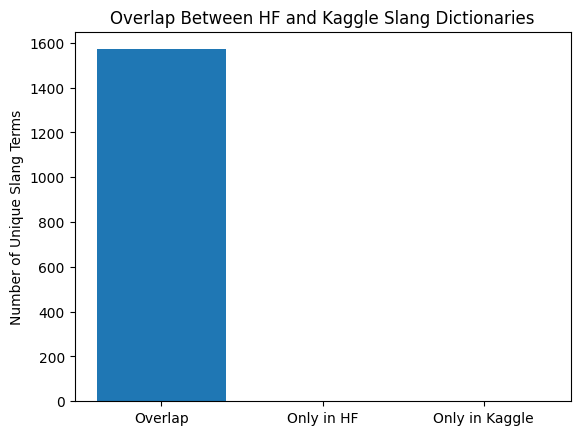

In [16]:
import matplotlib.pyplot as plt

# --- Create sets of slang terms (normalized) ---
set_hf = set(slang_dict_hf["Slang"].astype(str).str.lower().str.strip())
set_kaggle = set(slang_dict_kaggle["Slang"].astype(str).str.lower().str.strip())

# --- Compute intersections and differences ---
intersection = set_hf.intersection(set_kaggle)
only_in_hf = set_hf - set_kaggle
only_in_kaggle = set_kaggle - set_hf

# --- Print summary ---
print("===== Slang Dictionary Comparison =====")
print(f"Total unique slang terms in HF dict: {len(set_hf)}")
print(f"Total unique slang terms in Kaggle dict: {len(set_kaggle)}")
print(f"Shared slang terms: {len(intersection)}")
print(f"Overlap relative to HF: {len(intersection) / len(set_hf) * 100:.2f}%")
print(f"Overlap relative to Kaggle: {len(intersection) / len(set_kaggle) * 100:.2f}%")

# --- Show examples of differences ---
print("\nExample slangs only in HF dataset:", list(only_in_hf)[:10])
print("Example slangs only in Kaggle dataset:", list(only_in_kaggle)[:10])

# --- Optional visual summary ---
labels = ['Overlap', 'Only in HF', 'Only in Kaggle']
values = [len(intersection), len(only_in_hf), len(only_in_kaggle)]

plt.bar(labels, values)
plt.title("Overlap Between HF and Kaggle Slang Dictionaries")
plt.ylabel("Number of Unique Slang Terms")
plt.show()


We proved that they contain the same Slang terms, therefore we do not need to update/merge them in any way.

Therefore we move on with the hugging face dataset since we acknoledge that the popularity column in dict_slang_kaggle is a feature that depends on region and time, so we decide to drop it and use the dict_slang_hf because the context column is useful to get accurate and more precise neutral examples. 